# **imports**

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent)) # Damit Dataset richtig erkannt wird

In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import PIL.Image as Image
import os
import cv2
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import math

from SelfAttention.self_attention import SelfAttention
from SelfAttention.MLP import MLP

from TransformerBlocks.ImageTransformerBlock import ImageTransformerBlock
from TransformerBlocks.PointTransformerBlock import PointTransformerBlock

from UNet import FeatureUNET
#from PointNet_.PointNet import PointNetAutoencoder, PointNetAutoencoder, PointNetEncoder2D
#from PointNet_.PointNetPreTrainer import PointNetPreTrainer
from Dataset.PH2ContourDataset import PH2ContourDataset
from ContourDiffusionModel import ContourDiffusionModel

# load **DATA**

In [3]:
dataset = PH2ContourDataset(base_path="..\PH2Dataset\PH2 Dataset images", n_punkte=200, img_size=(288, 384)) # eigentlich 576x768, aber das ist zu groß für die GPU. Wir testen erstmal mit 288x384, damit es schneller läuft.

# 2. DataLoader erstellen (z.B. 2 Bilder gleichzeitig verarbeiten)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, drop_last=True)

# 3. Testen, ob alles klappt:
for batch_images, batch_points, batch_masks in dataloader:
    print("Bild-Batch Form:", batch_images.shape)  
    print("Punkt-Batch Form:", batch_points.shape)     
    print("Masken-Batch Form:", batch_masks.shape)
    
    # Optional: break einfügen, wenn du wirklich nur den ersten Batch testen willst
    break


Datensatz geladen: 200 Bilder und Masken gefunden.
Bild-Batch Form: torch.Size([2, 3, 288, 384])
Punkt-Batch Form: torch.Size([2, 200, 2])
Masken-Batch Form: torch.Size([2, 1, 288, 384])


Bild-Batch Form: torch.Size([2, 3, 288, 384])
Punkt-Batch Form: torch.Size([2, 200, 2])
Masken-Batch Form: torch.Size([2, 1, 288, 384])


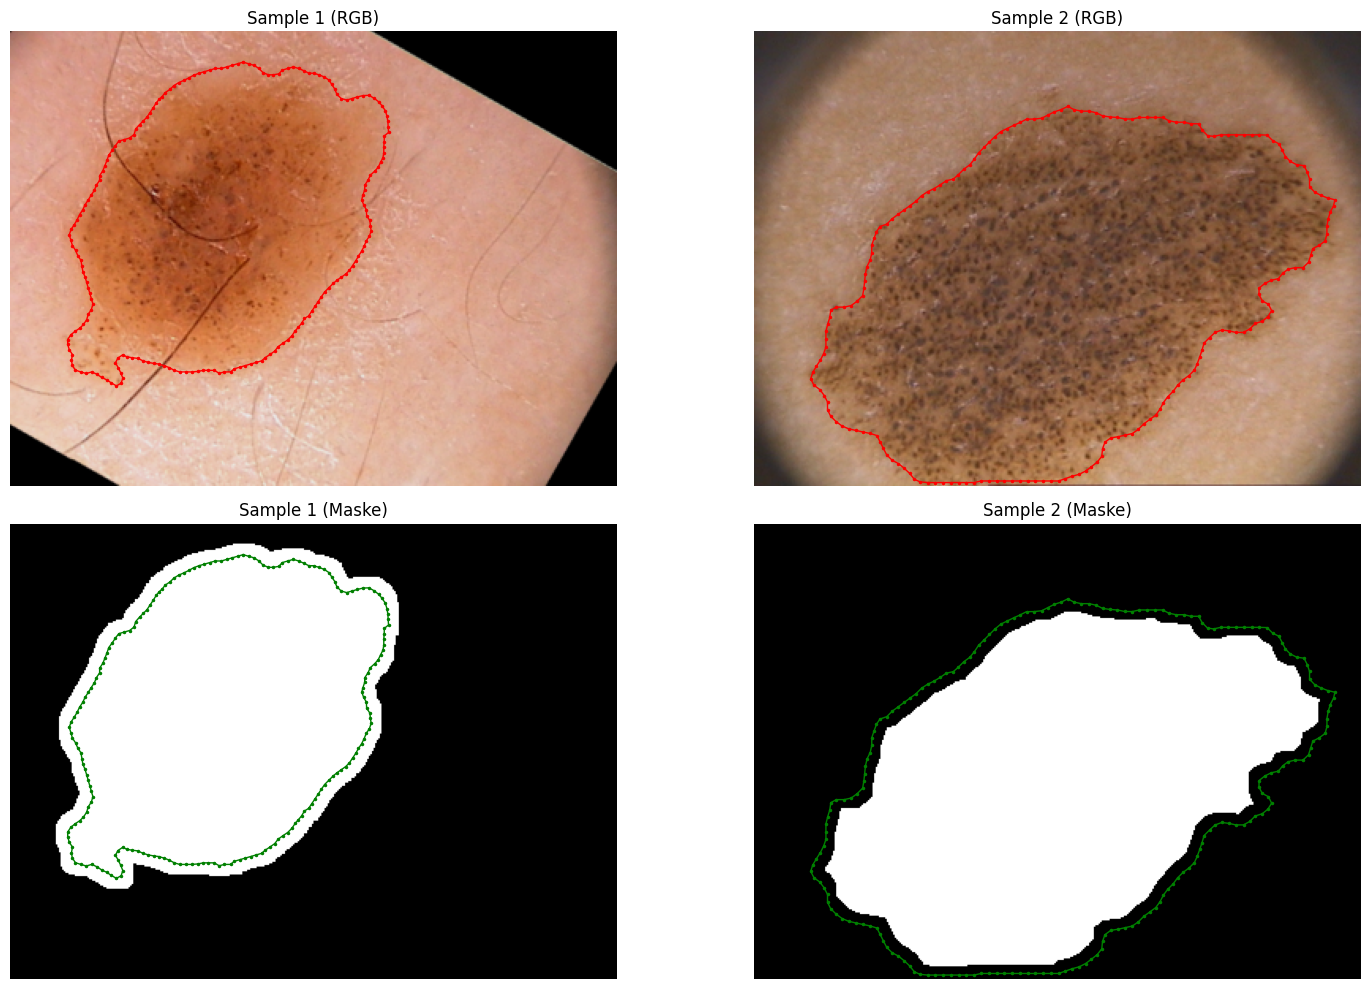

In [9]:

for batch_images, batch_points, batch_masks in dataloader:
    print("Bild-Batch Form:", batch_images.shape)  
    print("Punkt-Batch Form:", batch_points.shape) 
    print("Masken-Batch Form:", batch_masks.shape)
    
    # Plot aufrufen
    dataset.verify_dataset(batch_images, batch_points, batch_masks)
    break # Bricht nach dem ersten Batch ab

In [10]:
# Teste das neue Feature-U-Net
model = FeatureUNET(in_channels=4, out_features=64)
# Dummy-Bild muss ebenfalls 4 Kanäle haben (Batch, Channel, H, W)
test_bild = torch.randn(4, 4, 256, 256)

wetterkarte = model(test_bild)
for idxwetter, wetter in enumerate(wetterkarte):
    print(f"Wetterkarte {idxwetter}: {wetter.shape}")

# Erwartet: torch.Size([4, 64, 256, 256])

Wetterkarte 0: torch.Size([4, 256, 32, 32])
Wetterkarte 1: torch.Size([4, 128, 64, 64])
Wetterkarte 2: torch.Size([4, 64, 256, 256])


# **Diffusion Model**

## **PointNet** Pretraining

In [8]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#
#model = PointNetAutoencoder(num_points=200)
#
#trainer = PointNetPreTrainer(
#    model=model,
#    dataloader=dataloader,
#    device=device,
#    epochs=200
#)
#
#trainer.train()

In [9]:
#import matplotlib.pyplot as plt
#import torch
#
#trainer.model.eval()
#
#with torch.no_grad():
#
#    # Ein echtes Sample holen
#    echte_punkte = batch_points[0:1].to(trainer.device)
#
#    # Rekonstruktion
#    fake_punkte, _ = trainer.model(echte_punkte)
#
#    # Nach CPU + numpy
#    echt = echte_punkte[0].cpu().numpy()
#    fake = fake_punkte[0].cpu().numpy()
#
#    # Plot
#    plt.figure(figsize=(8, 8))
#
#    plt.scatter(
#        echt[:, 0],
#        echt[:, 1],
#        c='blue',
#        label='Echte Kontur',
#        alpha=0.5
#    )
#
#    plt.scatter(
#        fake[:, 0],
#        fake[:, 1],
#        c='red',
#        marker='x',
#        label='Rekonstruktion'
#    )
#
#    plt.legend()
#
#    plt.title("Autoencoder Rekonstruktion")
#
#    plt.axis("equal")
#
#    plt.show()

## **Diffusion Model**

# Test

In [11]:
import torch

# 1. Dummy-Daten erzeugen (als kämen sie aus deinem DataLoader)
batch_size = 4
dummy_bilder = torch.randn(batch_size, 4, 576, 768)
dummy_punkte = torch.rand(batch_size, 200, 2) * 2 - 1 # 4x 200 Punkte im Bereich [-1, 1]
dummy_zeit = torch.randint(0, 1000, (batch_size,))  # 4 zufällige Zeitschritte

# 2. Modelle initialisieren (UNSERE NEUE ARCHITEKTUR)
unet = FeatureUNET(in_channels=4, out_features=64)
diff_model = ContourDiffusionModel(n_punkte=200, hidden_dim=128) # context_dim ist weg!

# 3. Den Pipeline-Durchlauf testen!
with torch.no_grad():
    # Phase 1: U-Net (Die 3 Messfühler)
    wetterkarten_liste = unet(dummy_bilder)
    
    print("--- OUTPUT U-NET ---")
    print(f"Anzahl der extrahierten Karten: {len(wetterkarten_liste)}")
    print(f"Shape Karte 1 (Grob):   {wetterkarten_liste[0].shape}") # Erwartet: (4, 256, 72, 96)
    print(f"Shape Karte 2 (Mittel): {wetterkarten_liste[1].shape}") # Erwartet: (4, 128, 144, 192)
    print(f"Shape Karte 3 (Fein):   {wetterkarten_liste[2].shape}") # Erwartet: (4, 64, 576, 768)
    
    # Phase 2: Diffusions-Modell
    predicted_noise = diff_model(dummy_punkte, dummy_zeit, wetterkarten_liste)
    
    print("\n--- OUTPUT DIFFUSION ---")
    print(f"Shape Predicted Noise: {predicted_noise.shape}") # Erwartet: (4, 200, 2)
    
print("\nBOOM! Die neue Coarse-to-Fine Architektur steht und ist mathematisch zu 100 % kompatibel!")

--- OUTPUT U-NET ---
Anzahl der extrahierten Karten: 3
Shape Karte 1 (Grob):   torch.Size([4, 256, 72, 96])
Shape Karte 2 (Mittel): torch.Size([4, 128, 144, 192])
Shape Karte 3 (Fein):   torch.Size([4, 64, 576, 768])

--- OUTPUT DIFFUSION ---
Shape Predicted Noise: torch.Size([4, 200, 2])

BOOM! Die neue Coarse-to-Fine Architektur steht und ist mathematisch zu 100 % kompatibel!


In [12]:
import torch

# Standard DDPM Parameter
T = 1000 # 1000 Diffusions-Schritte
# Beta ist die Menge an Rauschen, die pro Schritt addiert wird.
# Es fängt winzig an (0.0001) und wird zum Schluss größer (0.02)
betas = torch.linspace(0.0001, 0.02, T) 

# Alphas definieren, wie viel vom Original-Bild noch übrig ist
alphas = 1.0 - betas
# alphas_cumprod ist die kumulierte Summe. (Gibt an, wie viel Original bei Schritt t noch da ist)
alphas_cumprod = torch.cumprod(alphas, dim=0)

# Helper-Funktion, um den richtigen Alpha-Wert für den Zeitschritt t der Batch auszuwählen
def extract(a, t, x_shape):
    batch_size = t.shape[0]
    out = a.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

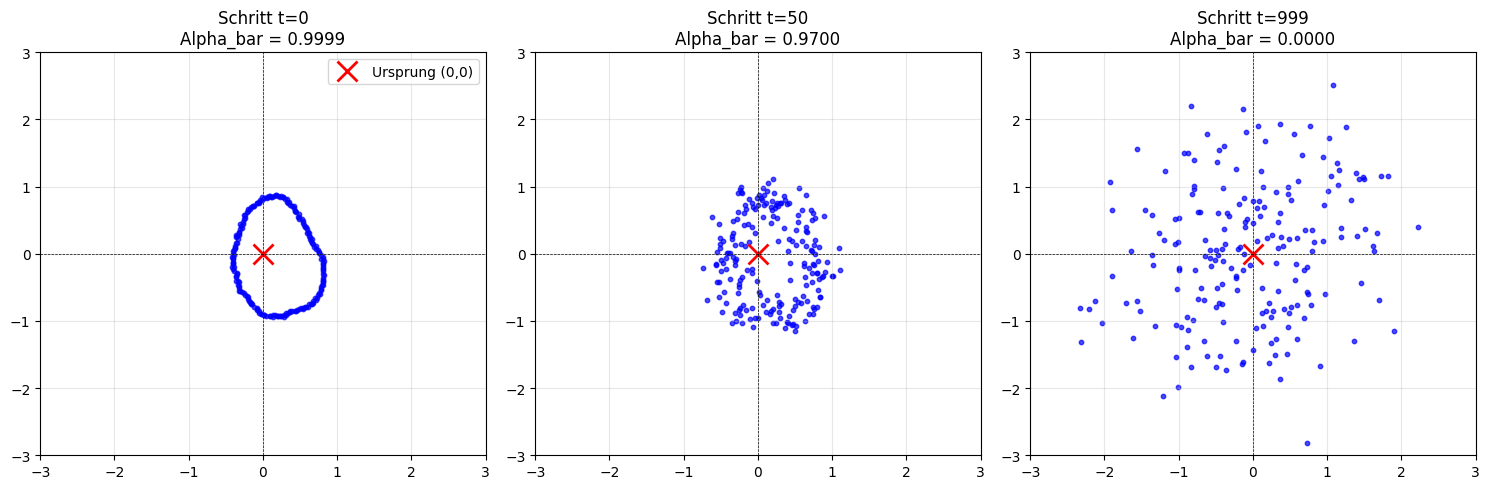

In [13]:
import matplotlib.pyplot as plt
import torch

# 1. Wir holen uns EIN Set an Punkten aus deinem Dataloader
batch_images, batch_points, batch_masks = next(iter(dataloader))
x_0 = batch_points[0]

# 2. Wir generieren das pure Zufallsrauschen (Gaussian Noise)
# Das ist exakt das, was dein 'noise = torch.randn_like(batch_points)' macht
noise = torch.randn_like(x_0)

# 3. Wir schauen uns drei Zeitpunkte an
zeitpunkte = [0, 50, 999]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, t_val in enumerate(zeitpunkte):
    # Wir holen uns den Skalierungswert für genau diesen Zeitpunkt t
    a_bar = alphas_cumprod[t_val].item()
    
    # DIE MAGISCHE FORMEL (Vorwärts-Diffusion)
    # x_t = (Echter Punkt * restliche Sichtbarkeit) + (Rauschen * aktuelle Rausch-Stärke)
    x_t = (x_0 * (a_bar ** 0.5)) + (noise * ((1 - a_bar) ** 0.5))
    
    # --- PLOTTING ---
    # Wir wandeln die Tensoren in Numpy-Arrays um
    pts = x_t.cpu().numpy()
    
    ax = axes[i]
    # Die Punkte zeichnen (blau)
    ax.scatter(pts[:, 0], pts[:, 1], c='blue', s=10, alpha=0.7)
    
    # Den Ursprung (0, 0) mit einem roten Kreuz markieren
    ax.plot(0, 0, 'rx', markersize=15, markeredgewidth=2, label="Ursprung (0,0)")
    
    # Die Achsen fest auf [-3, 3] setzen, damit wir den Shrink-Effekt sehen!
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(f"Schritt t={t_val}\nAlpha_bar = {a_bar:.4f}")
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()

In [15]:
import random 
import torch
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. MODELLE INITIALISIEREN ---
unet = FeatureUNET(in_channels=4, out_features=64).to(device)           # 4 = Image(3) +  Mask
diff_model = ContourDiffusionModel(n_punkte=200, hidden_dim=128).to(device)

# --- 2. OPTIMIZER & SETTINGS ---
optimizer = optim.AdamW(
    list(unet.parameters()) + list(diff_model.parameters()), 
    lr=1e-4, 
    weight_decay=1e-4
)

EPOCHS = 5
best_loss = float('inf')

unet.train()
diff_model.train()

print(f"Starte Diffusions-Training auf {device}.")
scaler = torch.amp.GradScaler('cuda')

training_history = {
    'epoch': [],
    'loss_total': []
}

# --- 3. DIE HAUPT-TRAININGSSCHLEIFE ---
for epoch in range(EPOCHS):
    epoch_loss_total = 0.0
    
    progress_bar = tqdm(dataloader, desc=f"Epoche {epoch+1}/{EPOCHS}")
    
    for batch_images, batch_points, batch_masks in progress_bar:
        # 1. Alle Tensoren ZUERST auf das richtige Device verschieben
        batch_images = batch_images.to(device)
        batch_masks = batch_masks.to(device)
        batch_points = batch_points.to(device) 
        
        # 2. DANN erst zusammenfügen
        img_with_mask = torch.cat([batch_images, batch_masks], dim=1)
        
        batch_size = batch_images.shape[0]
        
        optimizer.zero_grad()
        
        # Zufällige Zeitschritte ziehen
        t = torch.randint(0, T, (batch_size,), device=device).long()
        
        with torch.amp.autocast('cuda'):
            # Vorwärts-Diffusion: Rauschen auf Punkte addieren
            sqrt_alphas_cumprod_t = extract(torch.sqrt(alphas_cumprod), t, batch_points.shape)
            sqrt_one_minus_alphas_cumprod_t = extract(torch.sqrt(1. - alphas_cumprod), t, batch_points.shape)
            noise = torch.randn_like(batch_points)
            noisy_points = sqrt_alphas_cumprod_t * batch_points + sqrt_one_minus_alphas_cumprod_t * noise
            
            # U-Net + CFG Dropout
            wetterkarten_liste = unet(img_with_mask)
            if random.random() < 0.15:
                wetterkarten_liste = [torch.zeros_like(k) for k in wetterkarten_liste]
            
            # Diffusionsmodell sagt x0 vorher
            predicted_x0 = diff_model(noisy_points, t, wetterkarten_liste)
            predicted_x0 = torch.clamp(predicted_x0, -1.2, 1.2)
            
            # x0-Loss: gewichtet mit alphas_cumprod (unterdrückt hohe t)
            x0_weight = extract(alphas_cumprod, t, batch_points.shape).mean()
            loss_x0 = x0_weight * F.mse_loss(predicted_x0, batch_points)
            
            # Chain-Loss: hält Punkte als geschlossene Kette zusammen
            points_next = torch.roll(predicted_x0, shifts=-1, dims=1)
            loss_chain = torch.mean((predicted_x0 - points_next)**2)
            
            loss_total = loss_x0 + 0.01 * loss_chain
            
        # Optimierung
        scaler.scale(loss_total).backward()
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss_total += loss_total.item()
        
        progress_bar.set_postfix({
            "Loss": f"{loss_total.item():.4f}",
            "x0": f"{loss_x0.item():.4f}",
            "chain": f"{loss_chain.item():.4f}"
        })
        
    avg_loss_total = epoch_loss_total / len(dataloader)
    
    training_history['epoch'].append(epoch + 1)
    training_history['loss_total'].append(avg_loss_total)
    
    print(f"Epoche {epoch+1} beendet | Total: {avg_loss_total:.4f}")
    
    if avg_loss_total < best_loss:
        best_loss = avg_loss_total
        torch.save({
            'unet_state_dict': unet.state_dict(),
            'diff_model_state_dict': diff_model.state_dict(),
            'epoch': epoch,
            'loss': best_loss
        }, "best_end2end_model.pth")
        print(f"✅ Neuer Rekord! Bestes Modell in Epoche {epoch+1} gesichert (Loss: {best_loss:.4f})")

Starte Diffusions-Training auf cuda.


Epoche 1/5: 100%|██████████| 100/100 [00:28<00:00,  3.56it/s, Loss=0.0004, x0=0.0004, chain=0.0052]


Epoche 1 beendet | Total: 0.0336
✅ Neuer Rekord! Bestes Modell in Epoche 1 gesichert (Loss: 0.0336)


Epoche 2/5: 100%|██████████| 100/100 [00:24<00:00,  4.08it/s, Loss=0.0071, x0=0.0070, chain=0.0074]


Epoche 2 beendet | Total: 0.0156
✅ Neuer Rekord! Bestes Modell in Epoche 2 gesichert (Loss: 0.0156)


...

Epoche 3 beendet | Total: 0.0142
✅ Neuer Rekord! Bestes Modell in Epoche 3 gesichert (Loss: 0.0142)


Epoche 4/5: 100%|██████████| 100/100 [00:25<00:00,  3.96it/s, Loss=0.0052, x0=0.0052, chain=0.0021]


Epoche 4 beendet | Total: 0.0118
✅ Neuer Rekord! Bestes Modell in Epoche 4 gesichert (Loss: 0.0118)


Epoche 5/5: 100%|██████████| 100/100 [00:24<00:00,  4.06it/s, Loss=0.0186, x0=0.0186, chain=0.0015]

Epoche 5 beendet | Total: 0.0113
✅ Neuer Rekord! Bestes Modell in Epoche 5 gesichert (Loss: 0.0113)


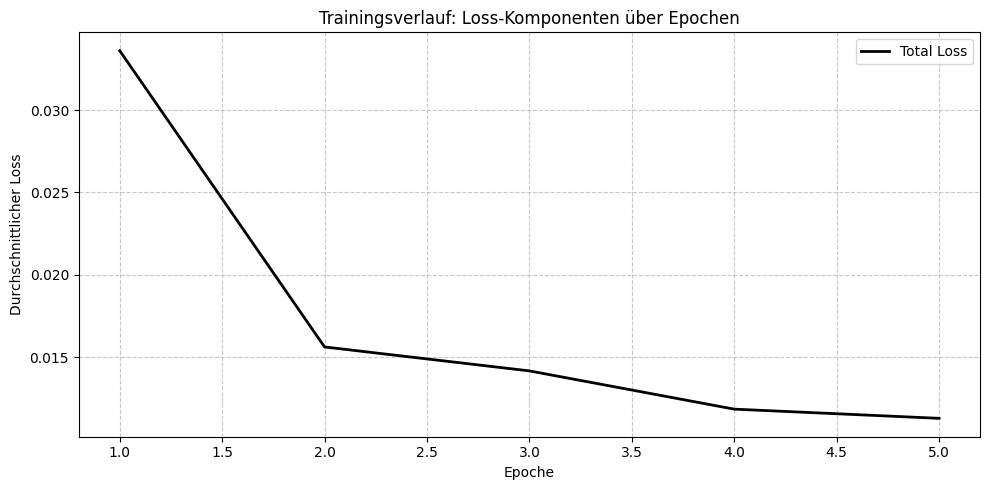

In [16]:
# WICHTIG: Die Keys müssen exakt mit dem Dictionary aus der Trainingsschleife übereinstimmen
plt.figure(figsize=(10, 5))

# Die drei Loss-Komponenten plotten
plt.plot(training_history['epoch'], training_history['loss_total'], marker='', linestyle='-', color='black', linewidth=2, label='Total Loss')
#plt.plot(training_history['epoch'], training_history['loss_noise'], marker='', linestyle='--', color='blue', alpha=0.7, label='Noise Loss (MSE)')
#plt.plot(training_history['epoch'], training_history['loss_struktur'], marker='', linestyle='-.', color='red', alpha=0.7, label='Struktur Loss (PointNet)')

plt.title("Trainingsverlauf: Loss-Komponenten über Epochen")
plt.xlabel("Epoche")
plt.ylabel("Durchschnittlicher Loss")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Sichert den Plot als Datei (verhindert Datenverlust bei VS Code Absturz)
plt.savefig("trainingsverlauf_loss.png", dpi=300)

# Zeigt den Plot zusätzlich an
plt.show()

In [17]:
import numpy as np
np.min(training_history['loss_total'])

np.float64(0.011279166364292905)

Sampling: 100%|██████████| 1000/1000 [00:15<00:00, 64.72it/s]


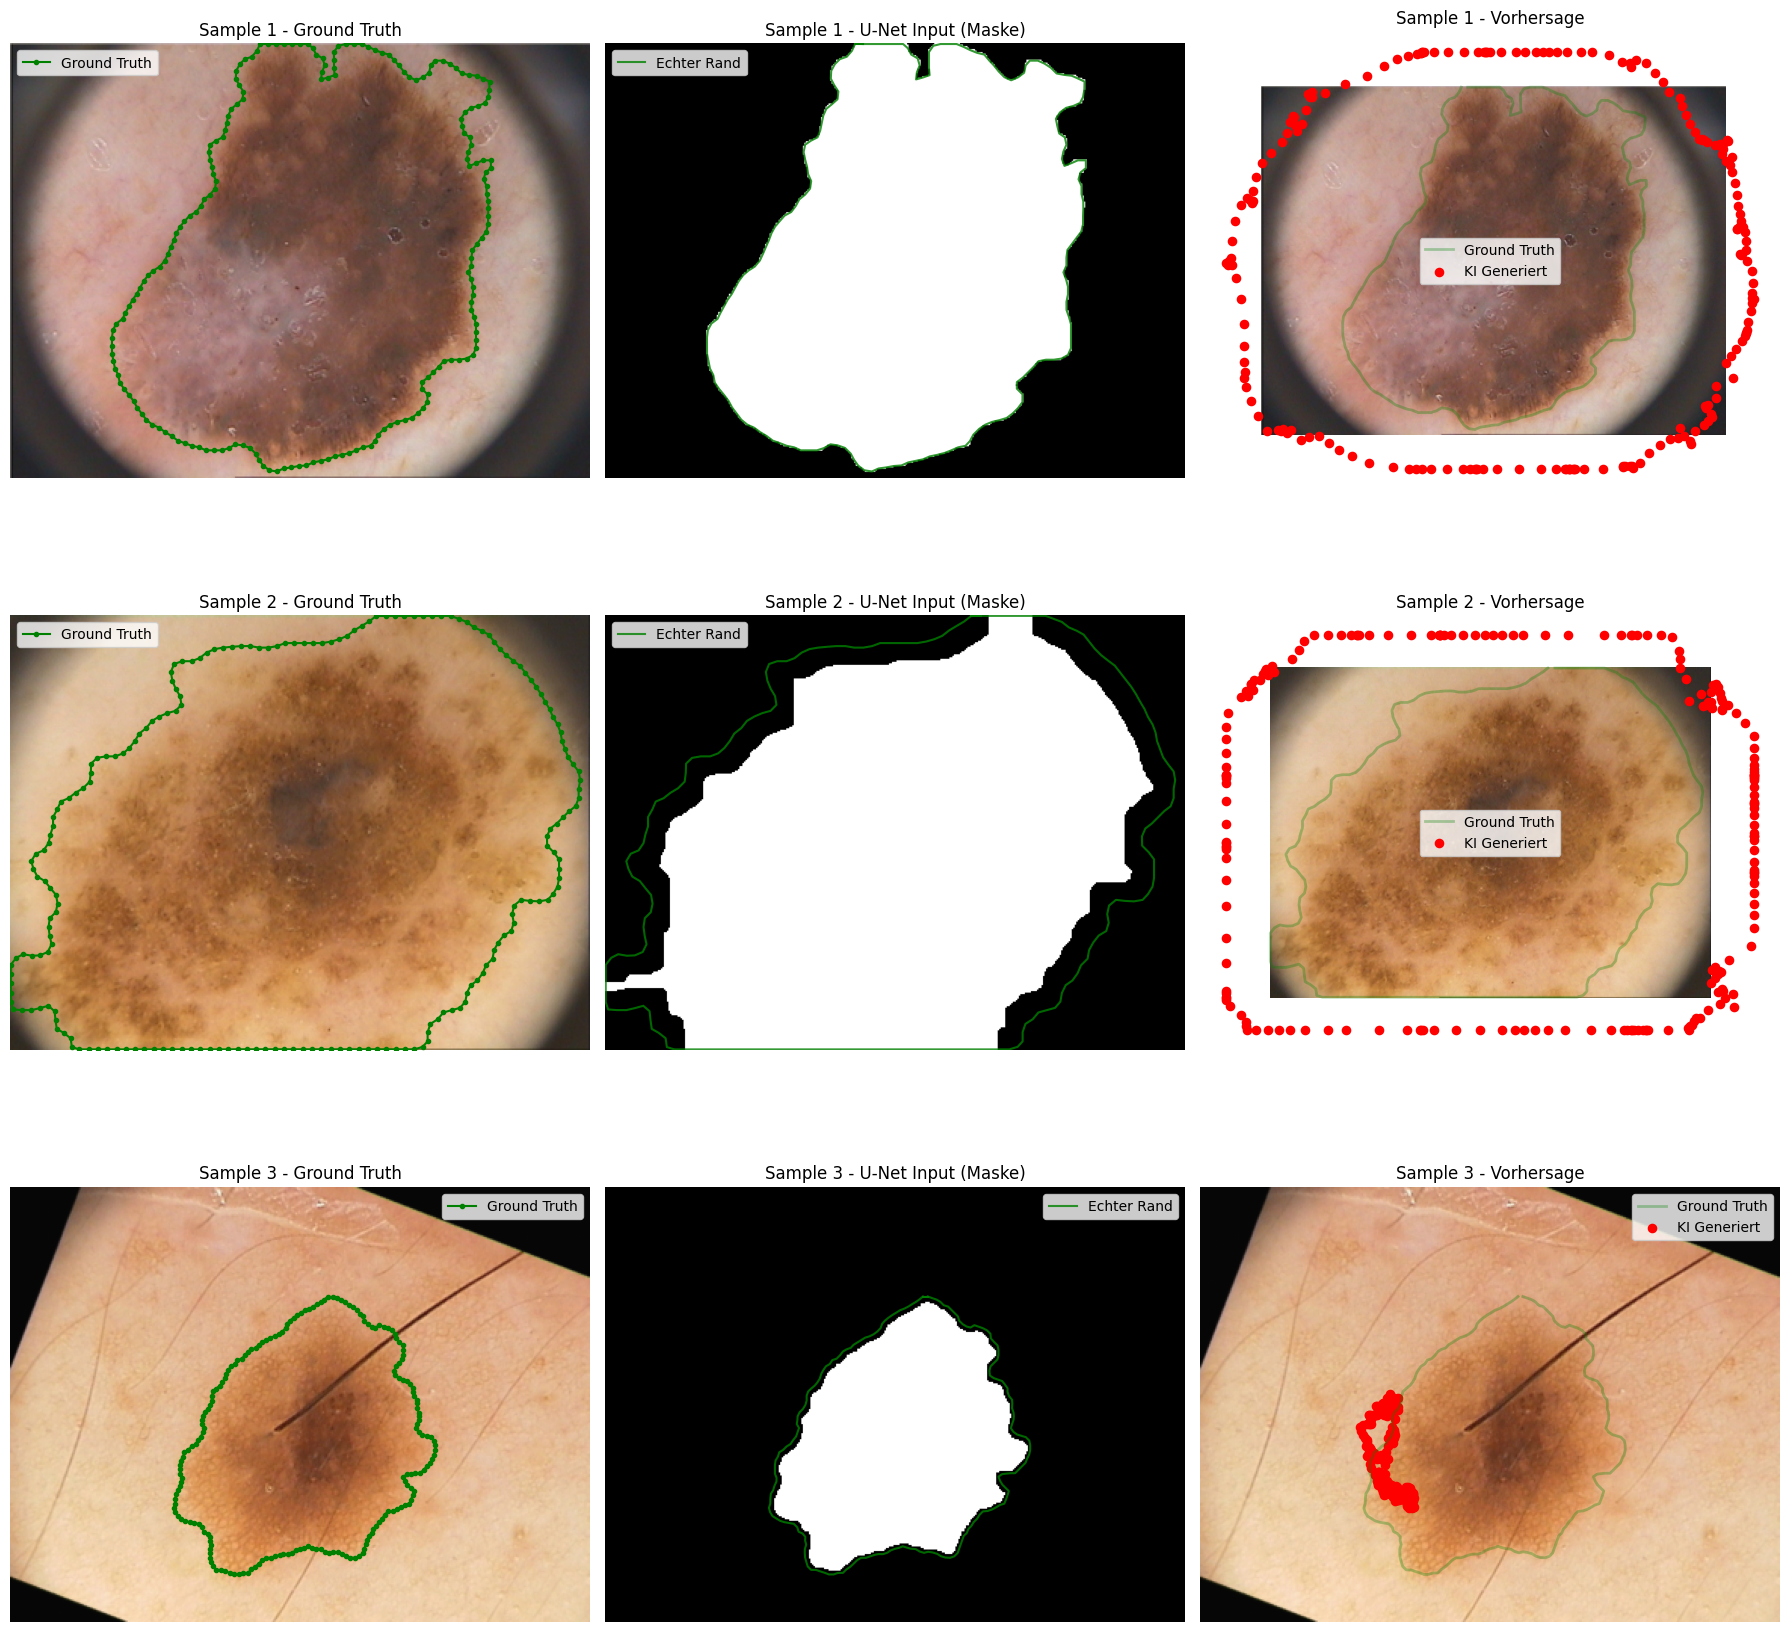

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

T = 1000
beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

unet.eval()
diff_model.eval()

# 1. Funktion anpassen: Sie braucht nun auch mask_tensor
def sample_contour(unet_model, diffusion_model, image_tensor, mask_tensor, T_steps=1000):
    with torch.no_grad():
        # Bild und Maske zusammenfügen [B, 4, H, W]
        img_with_mask = torch.cat([image_tensor, mask_tensor], dim=1).to(device)
        wetterkarte = unet_model(img_with_mask)
        
        x = torch.randn(1, 200, 2).to(device)
        
        for t in tqdm(reversed(range(0, T_steps)), desc="Sampling", total=T_steps):
            t_tensor = torch.tensor([t], device=device).long()
            
            # x0 direkt vorhersagen mit CFG
            with torch.amp.autocast('cuda'):
                x0_cond   = diffusion_model(x, t_tensor, wetterkarte)
                x0_uncond = diffusion_model(x, t_tensor, [torch.zeros_like(k) for k in wetterkarte])
                guidance_scale = 3.0
                predicted_x0 = x0_uncond + guidance_scale * (x0_cond - x0_uncond)
                predicted_x0 = torch.clamp(predicted_x0, -1.2, 1.2)
            
            # DDPM Posterior: q(x_{t-1} | x_t, x0)
            alpha_t     = alphas[t]
            alpha_t_bar = alphas_cumprod[t]
            beta_t      = betas[t]
            alpha_t_bar_prev = alphas_cumprod[t-1] if t > 0 else torch.tensor(1.0, device=device)
            
            coef1 = torch.sqrt(alpha_t_bar_prev) * beta_t / (1.0 - alpha_t_bar)
            coef2 = torch.sqrt(alpha_t) * (1.0 - alpha_t_bar_prev) / (1.0 - alpha_t_bar)
            posterior_mean = coef1 * predicted_x0 + coef2 * x
            
            if t > 0:
                posterior_var = (1.0 - alpha_t_bar_prev) / (1.0 - alpha_t_bar) * beta_t
                x = posterior_mean + torch.sqrt(posterior_var) * torch.randn_like(x)
            else:
                x = posterior_mean
                
    return x

# --- VISUALISIERUNG ---
# Wir ändern das Grid auf 3 Zeilen und 3 Spalten
fig, axes = plt.subplots(3, 3, figsize=(18, 18))

for i in range(3):
    test_images, test_points, test_masks = next(iter(dataloader))
    
    single_image = test_images[0].unsqueeze(0)
    single_mask = test_masks[0].unsqueeze(0)
    echte_punkte = test_points[0].numpy()

    generierte_punkte = sample_contour(unet, diff_model, single_image, single_mask, T_steps=T).cpu().squeeze().numpy()

    # Bild vorbereiten
    img_vis = single_image.squeeze().cpu().numpy().transpose(1, 2, 0)
    img_vis = (img_vis * 0.5) + 0.5
    img_vis = np.clip(img_vis, 0, 1)
    H, W = img_vis.shape[:2]

    # Maske für Matplotlib vorbereiten (1-Kanal Tensor zu 2D Array)
    mask_vis = single_mask.squeeze().cpu().numpy()

    gen_x = (generierte_punkte[:, 0] + 1.0) / 2.0 * (W - 1)
    gen_y = (generierte_punkte[:, 1] + 1.0) / 2.0 * (H - 1)
    echt_x = (echte_punkte[:, 0] + 1.0) / 2.0 * (W - 1)
    echt_y = (echte_punkte[:, 1] + 1.0) / 2.0 * (H - 1)

    # --- Spalte 1: Ground Truth ---
    axes[i, 0].imshow(img_vis)
    axes[i, 0].plot(echt_x, echt_y, 'g.-', markersize=6, linewidth=1.5, label="Ground Truth")
    axes[i, 0].plot([echt_x[-1], echt_x[0]], [echt_y[-1], echt_y[0]], 'g-', linewidth=1.5)
    axes[i, 0].set_title(f"Sample {i+1} - Ground Truth")
    axes[i, 0].legend()
    axes[i, 0].axis("off")

    # --- Spalte 2: U-Net Input (Maske) ---
    axes[i, 1].imshow(mask_vis, cmap='gray')
    # Den echten Rand als grüne Linie drüberlegen, um den Versatz durch Dilation/Erosion zu sehen
    axes[i, 1].plot(echt_x, echt_y, 'g-', alpha=0.8, linewidth=1.5, label="Echter Rand")
    axes[i, 1].plot([echt_x[-1], echt_x[0]], [echt_y[-1], echt_y[0]], 'g-', linewidth=1.5)
    axes[i, 1].set_title(f"Sample {i+1} - U-Net Input (Maske)")
    axes[i, 1].legend()
    axes[i, 1].axis("off")

    # --- Spalte 3: Modellvorhersage ---
    axes[i, 2].imshow(img_vis)
    axes[i, 2].plot(echt_x, echt_y, 'g-', alpha=0.3, linewidth=2, label="Ground Truth")
    axes[i, 2].scatter(gen_x, gen_y, c='red', s=35, label="KI Generiert")
    axes[i, 2].set_title(f"Sample {i+1} - Vorhersage")
    axes[i, 2].legend()
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("generierte_konturen_grid_mit_maske.png", bbox_inches='tight', dpi=300)
plt.show()